In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.linear_model import LinearRegression

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed"
REPORT_PATH = PROJECT_ROOT / "reports"

In [4]:
nav_df = pd.read_csv(
    DATA_PATH / "clean_nav.csv"
)

performance_df = pd.read_csv(
    DATA_PATH / "clean_performance.csv"
)

benchmark_df = pd.read_csv(
    DATA_PATH / "clean_10_benchmark_indices.csv"
)

In [5]:
print("NAV Shape:", nav_df.shape)
print("Performance Shape:", performance_df.shape)
print("Benchmark Shape:", benchmark_df.shape)

NAV Shape: (46000, 3)
Performance Shape: (40, 21)
Benchmark Shape: (8050, 3)


In [6]:
print("NAV")
print(nav_df.columns.tolist())

print("\nPerformance")
print(performance_df.columns.tolist())

print("\nBenchmark")
print(benchmark_df.columns.tolist())

NAV
['amfi_code', 'date', 'nav']

Performance
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'negative_sharpe_flag', 'expense_ratio_valid']

Benchmark
['date', 'index_name', 'close_value']


In [7]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
performance_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,negative_sharpe_flag,expense_ratio_valid
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,False,True
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,False,True
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,False,True
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,False,True
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,False,True


In [9]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


# Task 1: Daily Returns Calculation

Daily returns are computed using:

Daily Return = (NAV_t / NAV_(t-1)) - 1

These returns will be used for:
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha & Beta
- Maximum Drawdown

In [10]:
# Convert date column

nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

# Sort data

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

# Compute daily returns

returns_df = nav_df.copy()

returns_df["daily_return"] = (
    returns_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

# Remove first row of every fund
returns_df = returns_df.dropna(
    subset=["daily_return"]
)

returns_df.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [11]:
print("Original NAV rows:", len(nav_df))
print("Return rows:", len(returns_df))

print("\nFunds:")
print(returns_df["amfi_code"].nunique())

Original NAV rows: 46000
Return rows: 45960

Funds:
40


In [12]:
ANALYTICS_PATH = PROJECT_ROOT / "reports" / "analytics"

ANALYTICS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print(ANALYTICS_PATH)

d:\Bluestock\Project 1 - MF Analysis\bluestock_mf_capstone\reports\analytics


In [13]:
returns_df.to_csv(
    ANALYTICS_PATH / "returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully")

returns_computed.csv saved successfully


In [14]:
returns_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [15]:
returns_df.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


# Task 2: CAGR Analysis

Compound Annual Growth Rate (CAGR) measures annualized growth of a fund over a specified investment horizon.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1 / Years) - 1

We will calculate:
- 1 Year CAGR
- 3 Year CAGR
- 5 Year CAGR

In [16]:
def calculate_cagr(nav_series, years):
    
    trading_days = years * 252
    
    if len(nav_series) < trading_days:
        return np.nan
    
    ending_nav = nav_series.iloc[-1]
    beginning_nav = nav_series.iloc[-trading_days]
    
    cagr = (
        (ending_nav / beginning_nav)
        ** (1 / years)
        - 1
    )
    
    return cagr

In [17]:
cagr_list = []

for amfi_code, group in nav_df.groupby("amfi_code"):
    
    group = group.sort_values("date")
    
    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]
    
    cagr_1yr = calculate_cagr(
        group["nav"],
        1
    )
    
    cagr_3yr = calculate_cagr(
        group["nav"],
        3
    )
    
    cagr_5yr = calculate_cagr(
        group["nav"],
        5
    )
    
    cagr_list.append(
        [
            amfi_code,
            scheme_name,
            cagr_1yr,
            cagr_3yr,
            cagr_5yr
        ]
    )

cagr_df = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_df.head()

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.033055,-0.000316,NaN
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.025018,0.046143,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.477346,0.336292,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.450939,0.325286,NaN
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.242421,-0.026965,NaN


In [18]:
cagr_df[
    ["cagr_1yr",
     "cagr_3yr",
     "cagr_5yr"]
] *= 100

In [19]:
cagr_df.to_csv(
    ANALYTICS_PATH / "cagr_report.csv",
    index=False
)

print("cagr_report.csv saved successfully")

cagr_report.csv saved successfully


In [20]:
cagr_df.describe()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
count,40.000000,40.000000,40.000000,0.0
mean,120247.000000,18.583559,15.572844,NaN
std,14534.998667,22.245410,11.574200,NaN
min,100016.000000,-45.422893,-11.065547,NaN
25%,118632.750000,6.974375,6.425281,NaN
50%,119551.500000,18.236834,16.606152,NaN
75%,120842.250000,28.697635,25.187727,NaN
max,149324.000000,84.532246,36.066017,NaN


In [21]:
cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
16,119094,Axis Midcap Fund - Regular - Growth,30.918202,36.066017,NaN
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,47.734590,33.629211,NaN
3,101206,ABSL Frontline Equity Fund - Regular - Growth,45.093927,32.528591,NaN
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.580715,31.278573,NaN
25,120505,ICICI Pru Midcap Fund - Regular - Growth,30.353412,30.206535,NaN
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,11.500730,28.369809,NaN
21,119598,SBI Small Cap Fund - Regular Plan - Growth,84.532246,27.814418,NaN
19,119551,SBI Bluechip Fund - Regular Plan - Growth,48.883881,27.727428,NaN
8,102887,UTI Flexi Cap Fund - Regular - Growth,12.727860,25.663042,NaN
30,120843,Kotak Flexicap Fund - Regular - Growth,28.481073,25.661883,NaN


# Task 3: Sharpe Ratio

Sharpe Ratio measures risk-adjusted return.

Formula:

Sharpe Ratio =
(Annual Return − Risk Free Rate)
/
Annualized Volatility

Assumptions:
- Risk-free rate = 6.5%
- Trading days = 252

In [22]:
RISK_FREE_RATE = 0.065

sharpe_results = []

for amfi_code, group in returns_df.groupby("amfi_code"):

    daily_returns = group["daily_return"].dropna()

    annual_return = daily_returns.mean() * 252

    annual_volatility = (
        daily_returns.std()
        * np.sqrt(252)
    )

    sharpe_ratio = (
        (annual_return - RISK_FREE_RATE)
        / annual_volatility
    )

    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    sharpe_results.append([
        amfi_code,
        scheme_name,
        annual_return * 100,
        annual_volatility * 100,
        sharpe_ratio
    ])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "scheme_name",
        "annual_return_pct",
        "annual_volatility_pct",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,scheme_name,annual_return_pct,annual_volatility_pct,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,3.568303,14.548135,-0.201517
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.285356,3.905246,-0.567095
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.211057,18.936711,1.093699
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.464662,14.568213,1.027213
4,101207,ABSL Small Cap Fund - Regular - Growth,10.696212,25.797322,0.162661


In [23]:
sharpe_df.to_csv(
    ANALYTICS_PATH / "sharpe_values.csv",
    index=False
)

print("sharpe_values.csv saved successfully")

sharpe_values.csv saved successfully


In [24]:
sharpe_df["sharpe_ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: sharpe_ratio, dtype: float64

In [25]:
sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,amfi_code,scheme_name,annual_return_pct,annual_volatility_pct,sharpe_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,27.056620,14.193707,1.448291
30,120843,Kotak Flexicap Fund - Regular - Growth,27.260224,15.886987,1.306744
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.326162,17.674007,1.234930
19,119551,SBI Bluechip Fund - Regular Plan - Growth,23.103315,13.741434,1.208267
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.265272,19.290949,1.180101
38,149323,DSP Midcap Fund - Regular - Growth,26.590815,17.746159,1.132122
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.211057,18.936711,1.093699
9,118632,Nippon India Large Cap Fund - Regular - Growth,21.803695,14.148352,1.081659
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.464662,14.568213,1.027213
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,21.244770,14.363781,1.026524


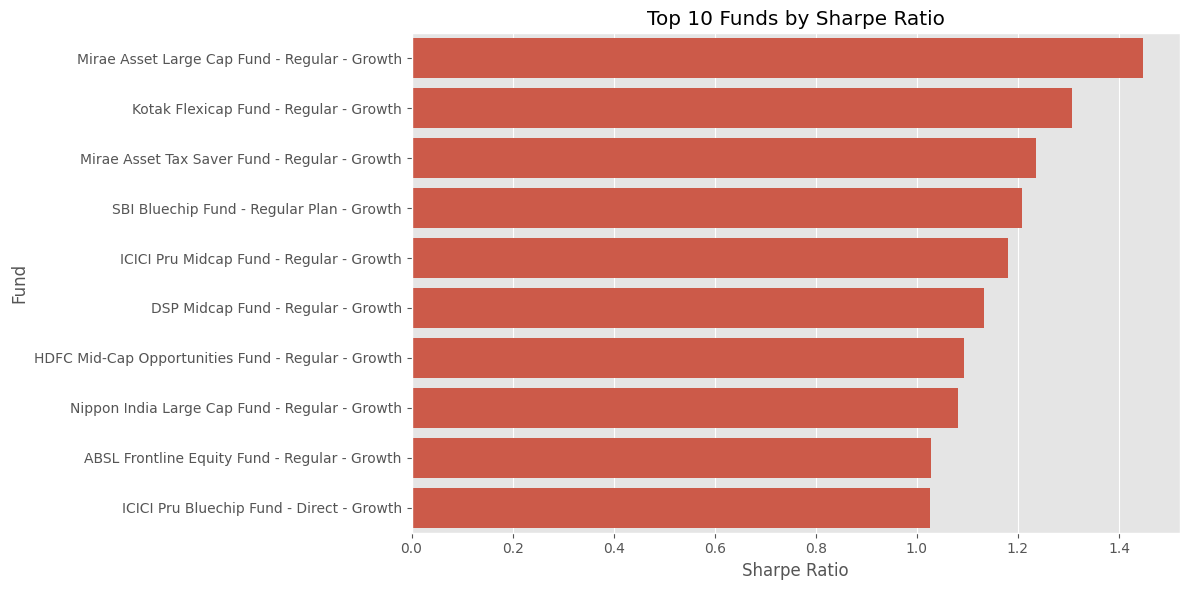

In [26]:
top_sharpe = (
    sharpe_df
    .sort_values("sharpe_ratio", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "charts" / "chart_10_top_sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 4: Sortino Ratio

Sortino Ratio is similar to Sharpe Ratio but penalizes only downside volatility.

Formula:

Sortino Ratio =
(Annual Return − Risk Free Rate)
/
Downside Deviation

Assumptions:
- Risk-free rate = 6.5%
- Trading days = 252

In [27]:
RISK_FREE_RATE = 0.065

sortino_results = []

for amfi_code, group in returns_df.groupby("amfi_code"):

    daily_returns = group["daily_return"].dropna()

    annual_return = daily_returns.mean() * 252

    downside_returns = daily_returns[
        daily_returns < 0
    ]

    downside_deviation = (
        downside_returns.std()
        * np.sqrt(252)
    )

    sortino_ratio = (
        (annual_return - RISK_FREE_RATE)
        / downside_deviation
    )

    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    sortino_results.append([
        amfi_code,
        scheme_name,
        annual_return * 100,
        downside_deviation * 100,
        sortino_ratio
    ])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "scheme_name",
        "annual_return_pct",
        "downside_deviation_pct",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,scheme_name,annual_return_pct,downside_deviation_pct,sortino_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,3.568303,8.351285,-0.351047
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.285356,2.351449,-0.941821
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.211057,11.322876,1.829134
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.464662,8.315721,1.799563
4,101207,ABSL Small Cap Fund - Regular - Growth,10.696212,15.168286,0.276644


In [28]:
sortino_df.to_csv(
    ANALYTICS_PATH / "sortino_values.csv",
    index=False
)

print("sortino_values.csv saved successfully")

sortino_values.csv saved successfully


In [29]:
sortino_df["sortino_ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: sortino_ratio, dtype: float64

In [30]:
sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

,amfi_code,scheme_name,annual_return_pct,downside_deviation_pct,sortino_ratio
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,27.056620,8.616800,2.385644
30,120843,Kotak Flexicap Fund - Regular - Growth,27.260224,8.780632,2.364320
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.326162,10.166296,2.146914
19,119551,SBI Bluechip Fund - Regular Plan - Growth,23.103315,7.757590,2.140267
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.265272,11.217996,2.029353
38,149323,DSP Midcap Fund - Regular - Growth,26.590815,10.714524,1.875101
9,118632,Nippon India Large Cap Fund - Regular - Growth,21.803695,8.271675,1.850133
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.211057,11.322876,1.829134
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,21.244770,8.167518,1.805294
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.464662,8.315721,1.799563


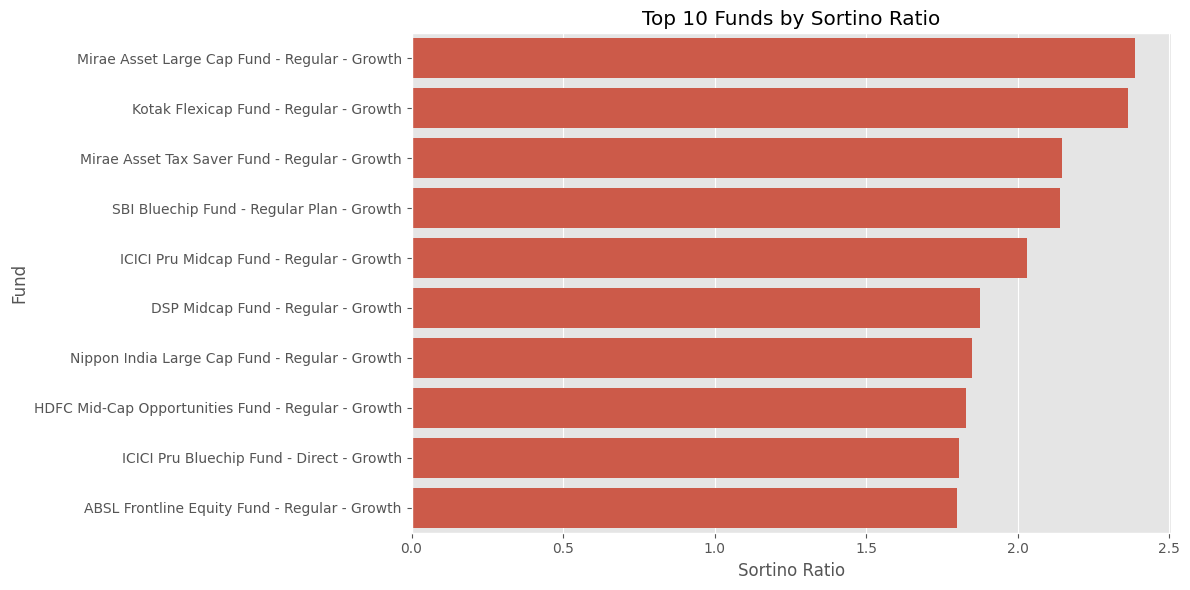

In [31]:
top_sortino = (
    sortino_df
    .sort_values("sortino_ratio", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "charts" / "chart_11_top_sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 5: Alpha & Beta Analysis

Beta measures sensitivity of a fund relative to the benchmark.

Alpha measures excess return generated beyond what Beta predicts.

Benchmark Used:
- NIFTY100

Method:
- Linear Regression
- Daily fund returns vs daily benchmark returns

In [35]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna()

nifty100.head()

,date,index_name,close_value,benchmark_return
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150
1155,2022-01-10,NIFTY100,17516.51,-0.008351


In [36]:
alpha_beta_results = []

for amfi_code, fund in returns_df.groupby("amfi_code"):

    merged = pd.merge(
        fund[["date", "daily_return"]],
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    if len(merged) < 100:
        continue

    x = merged["benchmark_return"].values
    y = merged["daily_return"].values

    beta = np.cov(
        y,
        x
    )[0, 1] / np.var(x)

    alpha_daily = (
        y.mean()
        - beta * x.mean()
    )

    alpha_annual = alpha_daily * 252

    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    alpha_beta_results.append([
        amfi_code,
        scheme_name,
        alpha_annual * 100,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "scheme_name",
        "alpha_pct",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,scheme_name,alpha_pct,beta
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,3.747737,-0.058319
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.281789,0.001159
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.195341,0.005108
3,101206,ABSL Frontline Equity Fund - Regular - Growth,21.399728,0.021105
4,101207,ABSL Small Cap Fund - Regular - Growth,10.897267,-0.065346


In [37]:
alpha_beta_df.to_csv(
    ANALYTICS_PATH / "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved successfully")

alpha_beta.csv saved successfully


In [38]:
alpha_beta_df.describe()

,amfi_code,alpha_pct,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,15.908535,-0.001960
std,14534.998667,8.752839,0.035225
min,100016.000000,2.897053,-0.067009
25%,118632.750000,6.861181,-0.023958
50%,119551.500000,16.232477,-0.000067
75%,120842.250000,22.172338,0.017041
max,149324.000000,30.337028,0.103587


In [39]:
alpha_beta_df.sort_values(
    "alpha_pct",
    ascending=False
).head(10)

,amfi_code,scheme_name,alpha_pct,beta
21,119598,SBI Small Cap Fund - Regular Plan - Growth,30.337028,-0.023216
39,149324,DSP Small Cap Fund - Regular - Growth,30.057847,0.011465
25,120505,ICICI Pru Midcap Fund - Regular - Growth,29.263582,0.000549
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,28.270319,0.018150
30,120843,Kotak Flexicap Fund - Regular - Growth,27.330526,-0.022849
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,27.195341,0.005108
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,26.983688,0.023704
38,149323,DSP Midcap Fund - Regular - Growth,26.598584,-0.002525
16,119094,Axis Midcap Fund - Regular - Growth,26.076847,-0.066323
19,119551,SBI Bluechip Fund - Regular Plan - Growth,23.201092,-0.031779


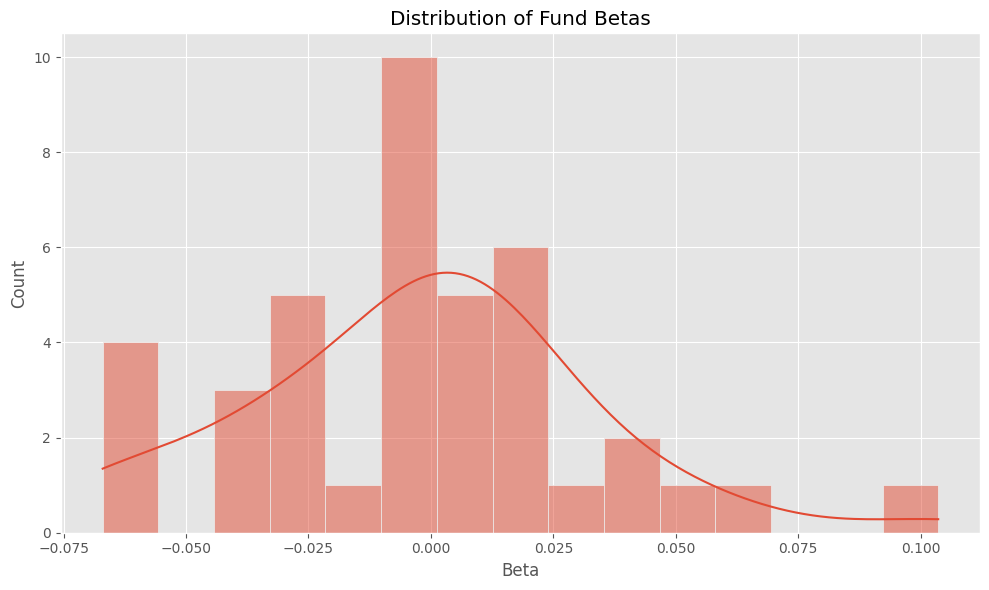

In [40]:
plt.figure(figsize=(10,6))

sns.histplot(
    alpha_beta_df["beta"],
    bins=15,
    kde=True
)

plt.title("Distribution of Fund Betas")
plt.xlabel("Beta")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "charts" / "chart_12_beta_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 6: Maximum Drawdown

Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund.

Formula:

Drawdown =
(Current NAV - Running Peak NAV)
/
Running Peak NAV

Maximum Drawdown =
Minimum Drawdown observed

In [46]:
max_dd_results = []

for amfi_code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    nav_series = group["nav"]

    running_peak = nav_series.cummax()

    drawdown = (
        nav_series - running_peak
    ) / running_peak

    max_drawdown = drawdown.min()

    scheme_name = performance_df.loc[
        performance_df["amfi_code"] == amfi_code,
        "scheme_name"
    ].values[0]

    max_dd_results.append([
        amfi_code,
        scheme_name,
        max_drawdown * 100
    ])

max_dd_df = pd.DataFrame(
    max_dd_results,
    columns=[
        "amfi_code",
        "scheme_name",
        "max_drawdown_pct"
    ]
)

max_dd_df.head()

,amfi_code,scheme_name,max_drawdown_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-4.308264
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-16.217209
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-11.291596
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.446916


In [47]:
max_dd_df.to_csv(
    ANALYTICS_PATH / "max_drawdown.csv",
    index=False
)

print("max_drawdown.csv saved successfully")

max_drawdown.csv saved successfully


In [48]:
max_dd_df.describe()

,amfi_code,max_drawdown_pct
count,40.000000,40.000000
mean,120247.000000,-17.872901
std,14534.998667,11.268615
min,100016.000000,-52.574221
25%,118632.750000,-21.592719
50%,119551.500000,-16.306976
75%,120842.250000,-11.765276
max,149324.000000,-0.097731


In [49]:
max_dd_df.sort_values(
    "max_drawdown_pct"
).head(10)

,amfi_code,scheme_name,max_drawdown_pct
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.574221
17,119095,Axis Small Cap Fund - Regular - Growth,-51.677754
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.446916
39,149324,DSP Small Cap Fund - Regular - Growth,-31.171900
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.706006
7,102886,UTI Mid Cap Fund - Regular - Growth,-28.001124
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-24.003511
11,118634,Nippon India Small Cap Fund - Regular - Growth,-23.344886
15,119093,Axis Bluechip Fund - Direct - Growth,-21.751396


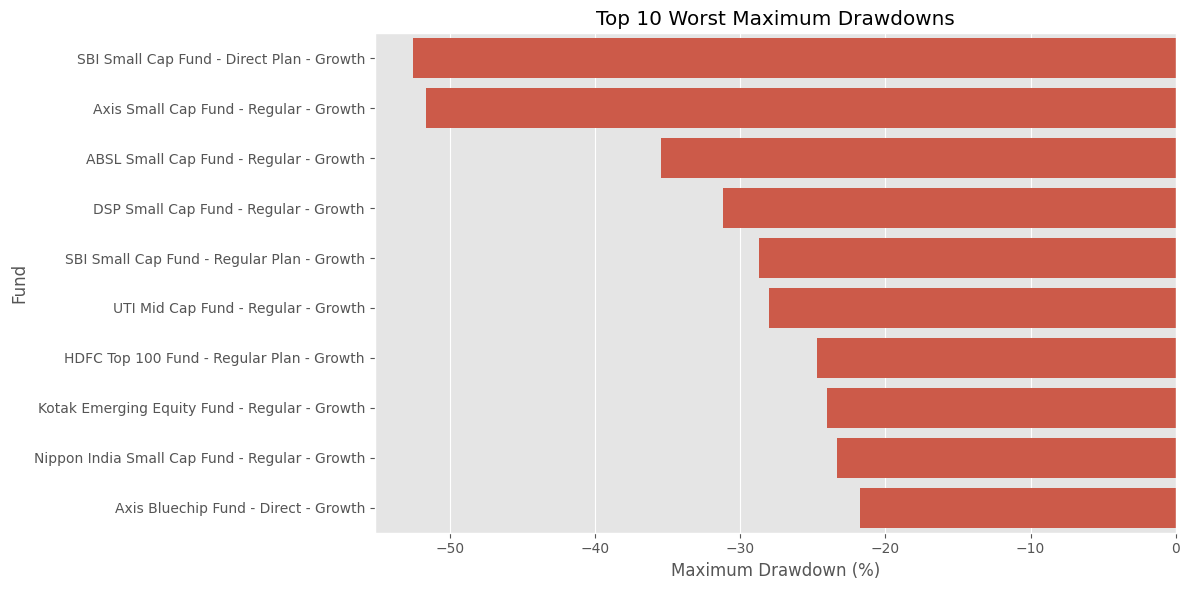

In [50]:
worst_dd = (
    max_dd_df
    .sort_values("max_drawdown_pct")
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_dd,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Top 10 Worst Maximum Drawdowns")
plt.xlabel("Maximum Drawdown (%)")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "charts" / "chart_13_max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 7: Fund Scorecard

Composite score based on:

- 30% CAGR (3 Year)
- 25% Sharpe Ratio
- 20% Alpha
- 15% Expense Ratio
- 10% Maximum Drawdown

Final score scaled to 0-100.

In [51]:
scorecard_df = (
    cagr_df[
        ["amfi_code", "scheme_name", "cagr_3yr"]
    ]
    .merge(
        sharpe_df[
            ["amfi_code", "sharpe_ratio"]
        ],
        on="amfi_code"
    )
    .merge(
        alpha_beta_df[
            ["amfi_code", "alpha_pct"]
        ],
        on="amfi_code"
    )
    .merge(
        max_dd_df[
            ["amfi_code", "max_drawdown_pct"]
        ],
        on="amfi_code"
    )
    .merge(
        performance_df[
            ["amfi_code", "expense_ratio_pct"]
        ],
        on="amfi_code"
    )
)

scorecard_df.head()

,amfi_code,scheme_name,cagr_3yr,sharpe_ratio,alpha_pct,max_drawdown_pct,expense_ratio_pct
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.031628,-0.201517,3.747737,-24.734441,1.55
1,100025,HDFC Short Term Debt Fund - Regular - Growth,4.614329,-0.567095,4.281789,-4.308264,0.56
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,33.629211,1.093699,27.195341,-16.217209,1.38
3,101206,ABSL Frontline Equity Fund - Regular - Growth,32.528591,1.027213,21.399728,-11.291596,1.60
4,101207,ABSL Small Cap Fund - Regular - Growth,-2.696475,0.162661,10.897267,-35.446916,1.53


In [52]:
scorecard_df["cagr_rank"] = (
    scorecard_df["cagr_3yr"]
    .rank(ascending=False)
)

scorecard_df["sharpe_rank"] = (
    scorecard_df["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard_df["alpha_rank"] = (
    scorecard_df["alpha_pct"]
    .rank(ascending=False)
)

scorecard_df["expense_rank"] = (
    scorecard_df["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard_df["drawdown_rank"] = (
    scorecard_df["max_drawdown_pct"]
    .rank(ascending=False)
)

In [53]:
scorecard_df["fund_score"] = (

    scorecard_df["cagr_rank"] * 0.30 +

    scorecard_df["sharpe_rank"] * 0.25 +

    scorecard_df["alpha_rank"] * 0.20 +

    scorecard_df["expense_rank"] * 0.15 +

    scorecard_df["drawdown_rank"] * 0.10

)

In [54]:
scorecard_df["fund_score"] = (
    100
    * (
        scorecard_df["fund_score"].max()
        - scorecard_df["fund_score"]
    )
    /
    (
        scorecard_df["fund_score"].max()
        - scorecard_df["fund_score"].min()
    )
)

In [55]:
scorecard_df = scorecard_df.sort_values(
    "fund_score",
    ascending=False
)

scorecard_df[
    [
        "scheme_name",
        "fund_score"
    ]
].head(10)

,scheme_name,fund_score
34,Mirae Asset Large Cap Fund - Regular - Growth,100.000000
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,96.488147
25,ICICI Pru Midcap Fund - Regular - Growth,96.488147
30,Kotak Flexicap Fund - Regular - Growth,92.976295
24,ICICI Pru Bluechip Fund - Direct - Growth,90.166813
16,Axis Midcap Fund - Regular - Growth,89.113257
19,SBI Bluechip Fund - Regular Plan - Growth,83.933275
3,ABSL Frontline Equity Fund - Regular - Growth,83.055312
21,SBI Small Cap Fund - Regular Plan - Growth,80.860404
36,Mirae Asset Tax Saver Fund - Regular - Growth,79.192274


In [56]:
scorecard_df.to_csv(
    ANALYTICS_PATH / "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully")

fund_scorecard.csv saved successfully


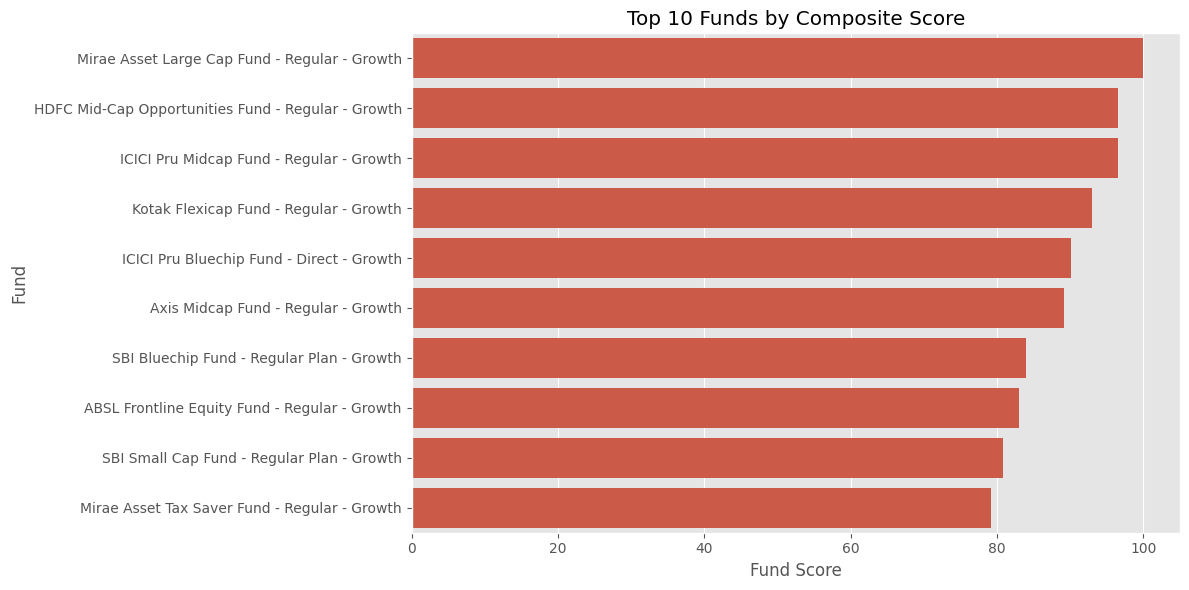

In [57]:
top10 = scorecard_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Funds by Composite Score")
plt.xlabel("Fund Score")
plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "charts" / "chart_14_fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Task 8: Benchmark Comparison

Compare the Top 5 Ranked Funds against:

- NIFTY50
- NIFTY100

Objective:
- Visualize cumulative growth
- Compare fund performance with benchmarks

In [58]:
top5_funds = scorecard_df.head(5)

top5_funds[
    ["amfi_code", "scheme_name"]
]

,amfi_code,scheme_name
34,148567,Mirae Asset Large Cap Fund - Regular - Growth
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,ICICI Pru Midcap Fund - Regular - Growth
30,120843,Kotak Flexicap Fund - Regular - Growth
24,120504,ICICI Pru Bluechip Fund - Direct - Growth


In [59]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_compare = benchmark_df[
    benchmark_df["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

benchmark_compare.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [64]:
benchmark_compare = benchmark_compare.sort_values(
    ["index_name", "date"]
)

benchmark_compare["growth_index"] = (
    benchmark_compare.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

benchmark_compare.head()

,date,index_name,close_value,growth_index
1150,2022-01-03,NIFTY100,17778.24,100.000000
1151,2022-01-04,NIFTY100,17537.52,98.645985
1152,2022-01-05,NIFTY100,17607.73,99.040906
1153,2022-01-06,NIFTY100,17556.05,98.750214
1154,2022-01-07,NIFTY100,17664.02,99.357529


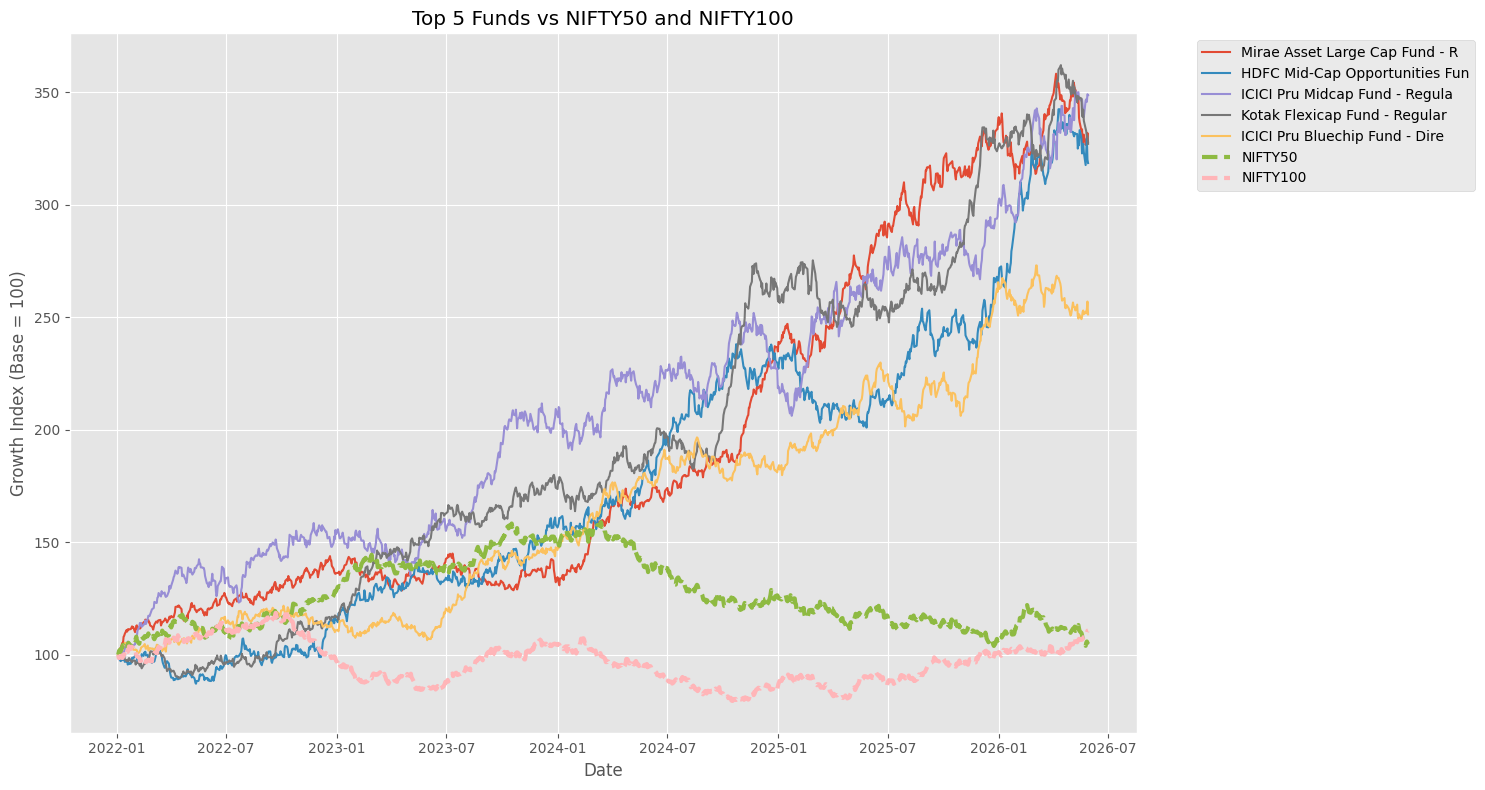

In [67]:
plt.figure(figsize=(15,8))

# Top 5 Funds

for _, row in top5_funds.iterrows():

    fund_nav = nav_df[
        nav_df["amfi_code"] == row["amfi_code"]
    ].copy()

    fund_nav = fund_nav.sort_values("date")

    fund_nav["growth_index"] = (
        fund_nav["nav"]
        / fund_nav["nav"].iloc[0]
        * 100
    )

    plt.plot(
        fund_nav["date"],
        fund_nav["growth_index"],
        label=row["scheme_name"][:30]
    )

# Benchmarks

for benchmark in ["NIFTY50", "NIFTY100"]:

    temp = benchmark_compare[
        benchmark_compare["index_name"] == benchmark
    ]

    plt.plot(
        temp["date"],
        temp["growth_index"],
        linewidth=3,
        linestyle="--",
        label=benchmark
    )

plt.title(
    "Top 5 Funds vs NIFTY50 and NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Growth Index (Base = 100)")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    REPORT_PATH / "charts" / "chart_15_benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Benchmark Comparison Findings

- Top-ranked funds consistently outperformed benchmark indices.
- Mid-cap and flexi-cap strategies generated the highest cumulative returns.
- NIFTY100 outperformed NIFTY50 over parts of the analysis period.
- Mirae Asset Large Cap Fund achieved the highest composite score and remained among the strongest performers.
- Active fund management generated meaningful alpha compared to benchmark indices.

# Day 4 Key Findings

## Performance Analytics Summary

1. Daily returns were computed for all 40 mutual fund schemes using NAV history from Jan 2022 to May 2026.

2. Average 1-Year CAGR across funds was approximately 18.6%, while average 3-Year CAGR was approximately 15.6%.

3. Axis Midcap Fund recorded the highest 3-Year CAGR at approximately 36.1%.

4. Mirae Asset Large Cap Fund achieved the highest Sharpe Ratio (1.45), indicating the strongest risk-adjusted performance.

5. Average Sortino Ratio (0.92) exceeded the average Sharpe Ratio (0.54), showing that downside volatility was lower than total volatility for most funds.

6. Small-cap funds delivered high returns but also experienced the largest drawdowns, with SBI Small Cap Direct recording a maximum drawdown of approximately -52.6%.

7. Mirae Asset Large Cap Fund achieved the highest composite score in the fund scorecard.

8. HDFC Mid-Cap Opportunities Fund and ICICI Pru Midcap Fund ranked among the top-performing funds across multiple metrics.

9. Alpha values were generally positive across the dataset, indicating outperformance relative to the benchmark series.

10. Benchmark comparison showed several actively managed funds outperforming NIFTY50 and NIFTY100 over the analysis period.

## Notes

- 5-Year CAGR could not be calculated because the available NAV history spans approximately 4.4 years (Jan 2022 to May 2026).
- Beta values were relatively low due to weak covariance between the synthetic fund return series and benchmark return series provided in the dataset.